# ADY201m — Phân tích và phân loại bệnh tim mạch
**Dữ liệu:** khôi phục từ PDF 649 trang do người dùng cung cấp; 70.000 dòng, 13 cột, ID không trùng.
Đây là bản đã chạy offline. Phần Watson Studio vẫn cần chạy lại trong tài khoản IBM riêng.
Mục tiêu: khảo sát mối liên hệ giữa các đặc trưng và CARDIO, làm sạch huyết áp,
kiểm định thống kê, xây dựng và so sánh các bộ phân loại theo đề.
Kết quả quan sát cho thấy sự liên hệ; không đủ để kết luận nguyên nhân bệnh hoặc dùng để chẩn đoán.

## 1. Thư viện, dữ liệu và kiểm tra chất lượng
Cài thư viện trong `requirements.txt` trước khi chạy. Notebook cần thư mục `data/` và `cardio_utils.py`.
Tuổi trong CSV gốc tính bằng ngày; chuyển sang số năm nguyên bằng `age // 365` theo ví dụ đề.
ID chỉ là mã định danh, không được đưa vào mô hình.

In [1]:
from pathlib import Path
import json, time, platform, importlib.metadata as metadata
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display, Image
from scipy import stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeClassifier
from sklearn.ensemble import (RandomForestClassifier,GradientBoostingClassifier,
    AdaBoostClassifier,BaggingClassifier,ExtraTreesClassifier,StackingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,
    roc_auc_score,confusion_matrix,classification_report)
from cardio_utils import IQRClipper
import joblib
ROOT=Path.cwd()
for folder in ['results','figures','data']: (ROOT/folder).mkdir(exist_ok=True)
RAW=ROOT/'data/cardio_train_raw.csv'
if not RAW.exists(): RAW=ROOT/'cardio_train_raw.csv'
raw=pd.read_csv(RAW,sep=';')
assert raw.shape==(70000,13) and raw.id.nunique()==70000
assert not raw.isna().any().any()
df=raw.copy()
df['age']=df['age']//365
features=['age','gender','height','weight','ap_hi','ap_lo','cholesterol','gluc','smoke','alco','active']
sns.set_theme(style='whitegrid',palette='deep')
def figure(name):
    plt.tight_layout()
    path=ROOT/'figures'/name
    plt.savefig(path,dpi=150,bbox_inches='tight')
    plt.close()
    display(Image(filename=str(path)))
quality={'rows':len(df),'columns':len(df.columns),'unique_ids':int(df.id.nunique()),
    'missing_values':int(df.isna().sum().sum()),'duplicate_feature_target_rows':int(df.drop(columns='id').duplicated().sum()),
    'disease_cases':int(df.cardio.sum()),'disease_rate':float(df.cardio.mean())}
display(pd.Series(quality,name='Kết quả kiểm tra'))
display(df.head(10))
display(df.describe().T)
df.describe().T.to_csv(ROOT/'results/descriptive_statistics.csv')
(ROOT/'results/data_quality.json').write_text(json.dumps(quality,indent=2),encoding='utf-8')

Out[0]: 175


rows                             70000.0000
columns                             13.0000
unique_ids                       70000.0000
missing_values                       0.0000
duplicate_feature_target_rows     3208.0000
disease_cases                    34979.0000
disease_rate                         0.4997
Name: Kết quả kiểm tra, dtype: float64

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,2,51,1,165,64.0,130,70,3,1,0,0,0,1
3,3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,4,47,1,156,56.0,100,60,1,1,0,0,0,0
5,8,60,1,151,67.0,120,80,2,2,0,0,0,0
6,9,60,1,157,93.0,130,80,3,1,0,0,1,0
7,12,61,2,178,95.0,130,90,3,3,0,0,1,1
8,13,48,1,158,71.0,110,70,1,1,0,0,1,0
9,14,54,1,164,68.0,110,60,1,1,0,0,0,0


,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,52.840671,6.766774,29.0,48.00,53.0,58.00,64.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


## 2. Phân tích khám phá và trực quan hóa
AGE đã đổi sang năm. CHOLESTEROL/GLUC: 1 bình thường, 2 cao, 3 rất cao.
SMOKE/ALCO/ACTIVE/CARDIO: 0 không, 1 có; GENDER là mã 1/2 trong dữ liệu.
Các hồ sơ trùng đặc trưng được giữ để tái hiện bài mẫu vì ID riêng và không đủ căn cứ xác định cùng bệnh nhân.

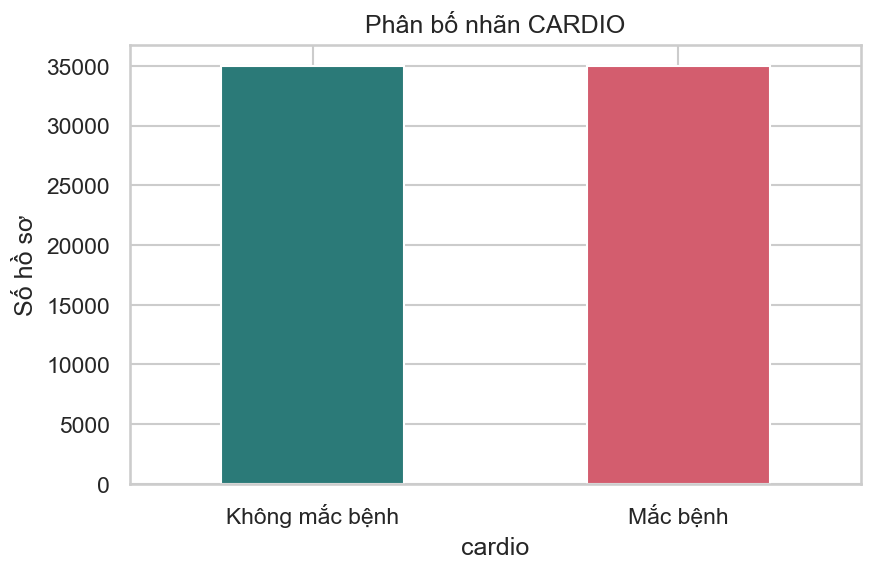

cardio         1.000000
age            0.237985
cholesterol    0.221147
weight         0.181660
gluc           0.089307
ap_lo          0.065719
ap_hi          0.054475
gender         0.008109
alco          -0.007330
height        -0.010821
smoke         -0.015486
active        -0.035653
Name: cardio, dtype: float64

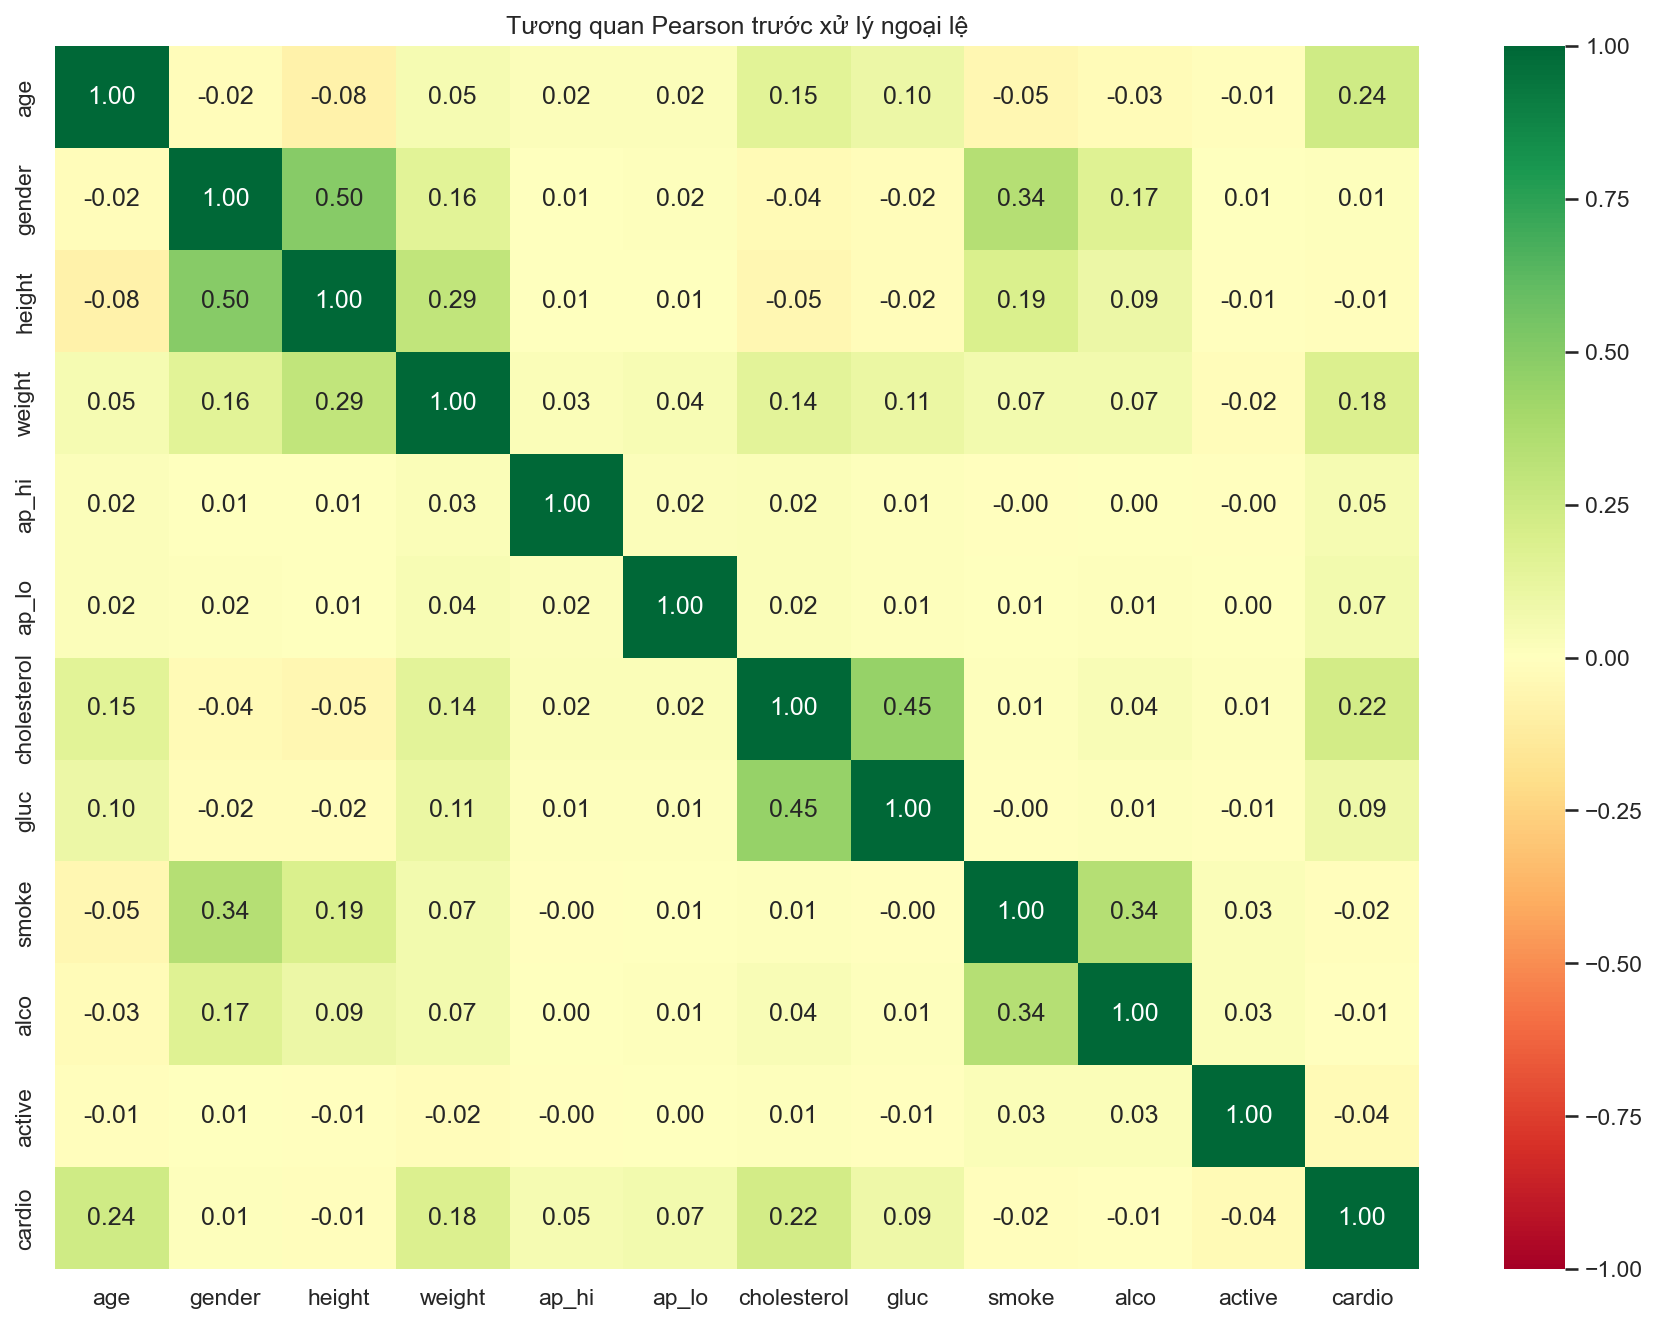

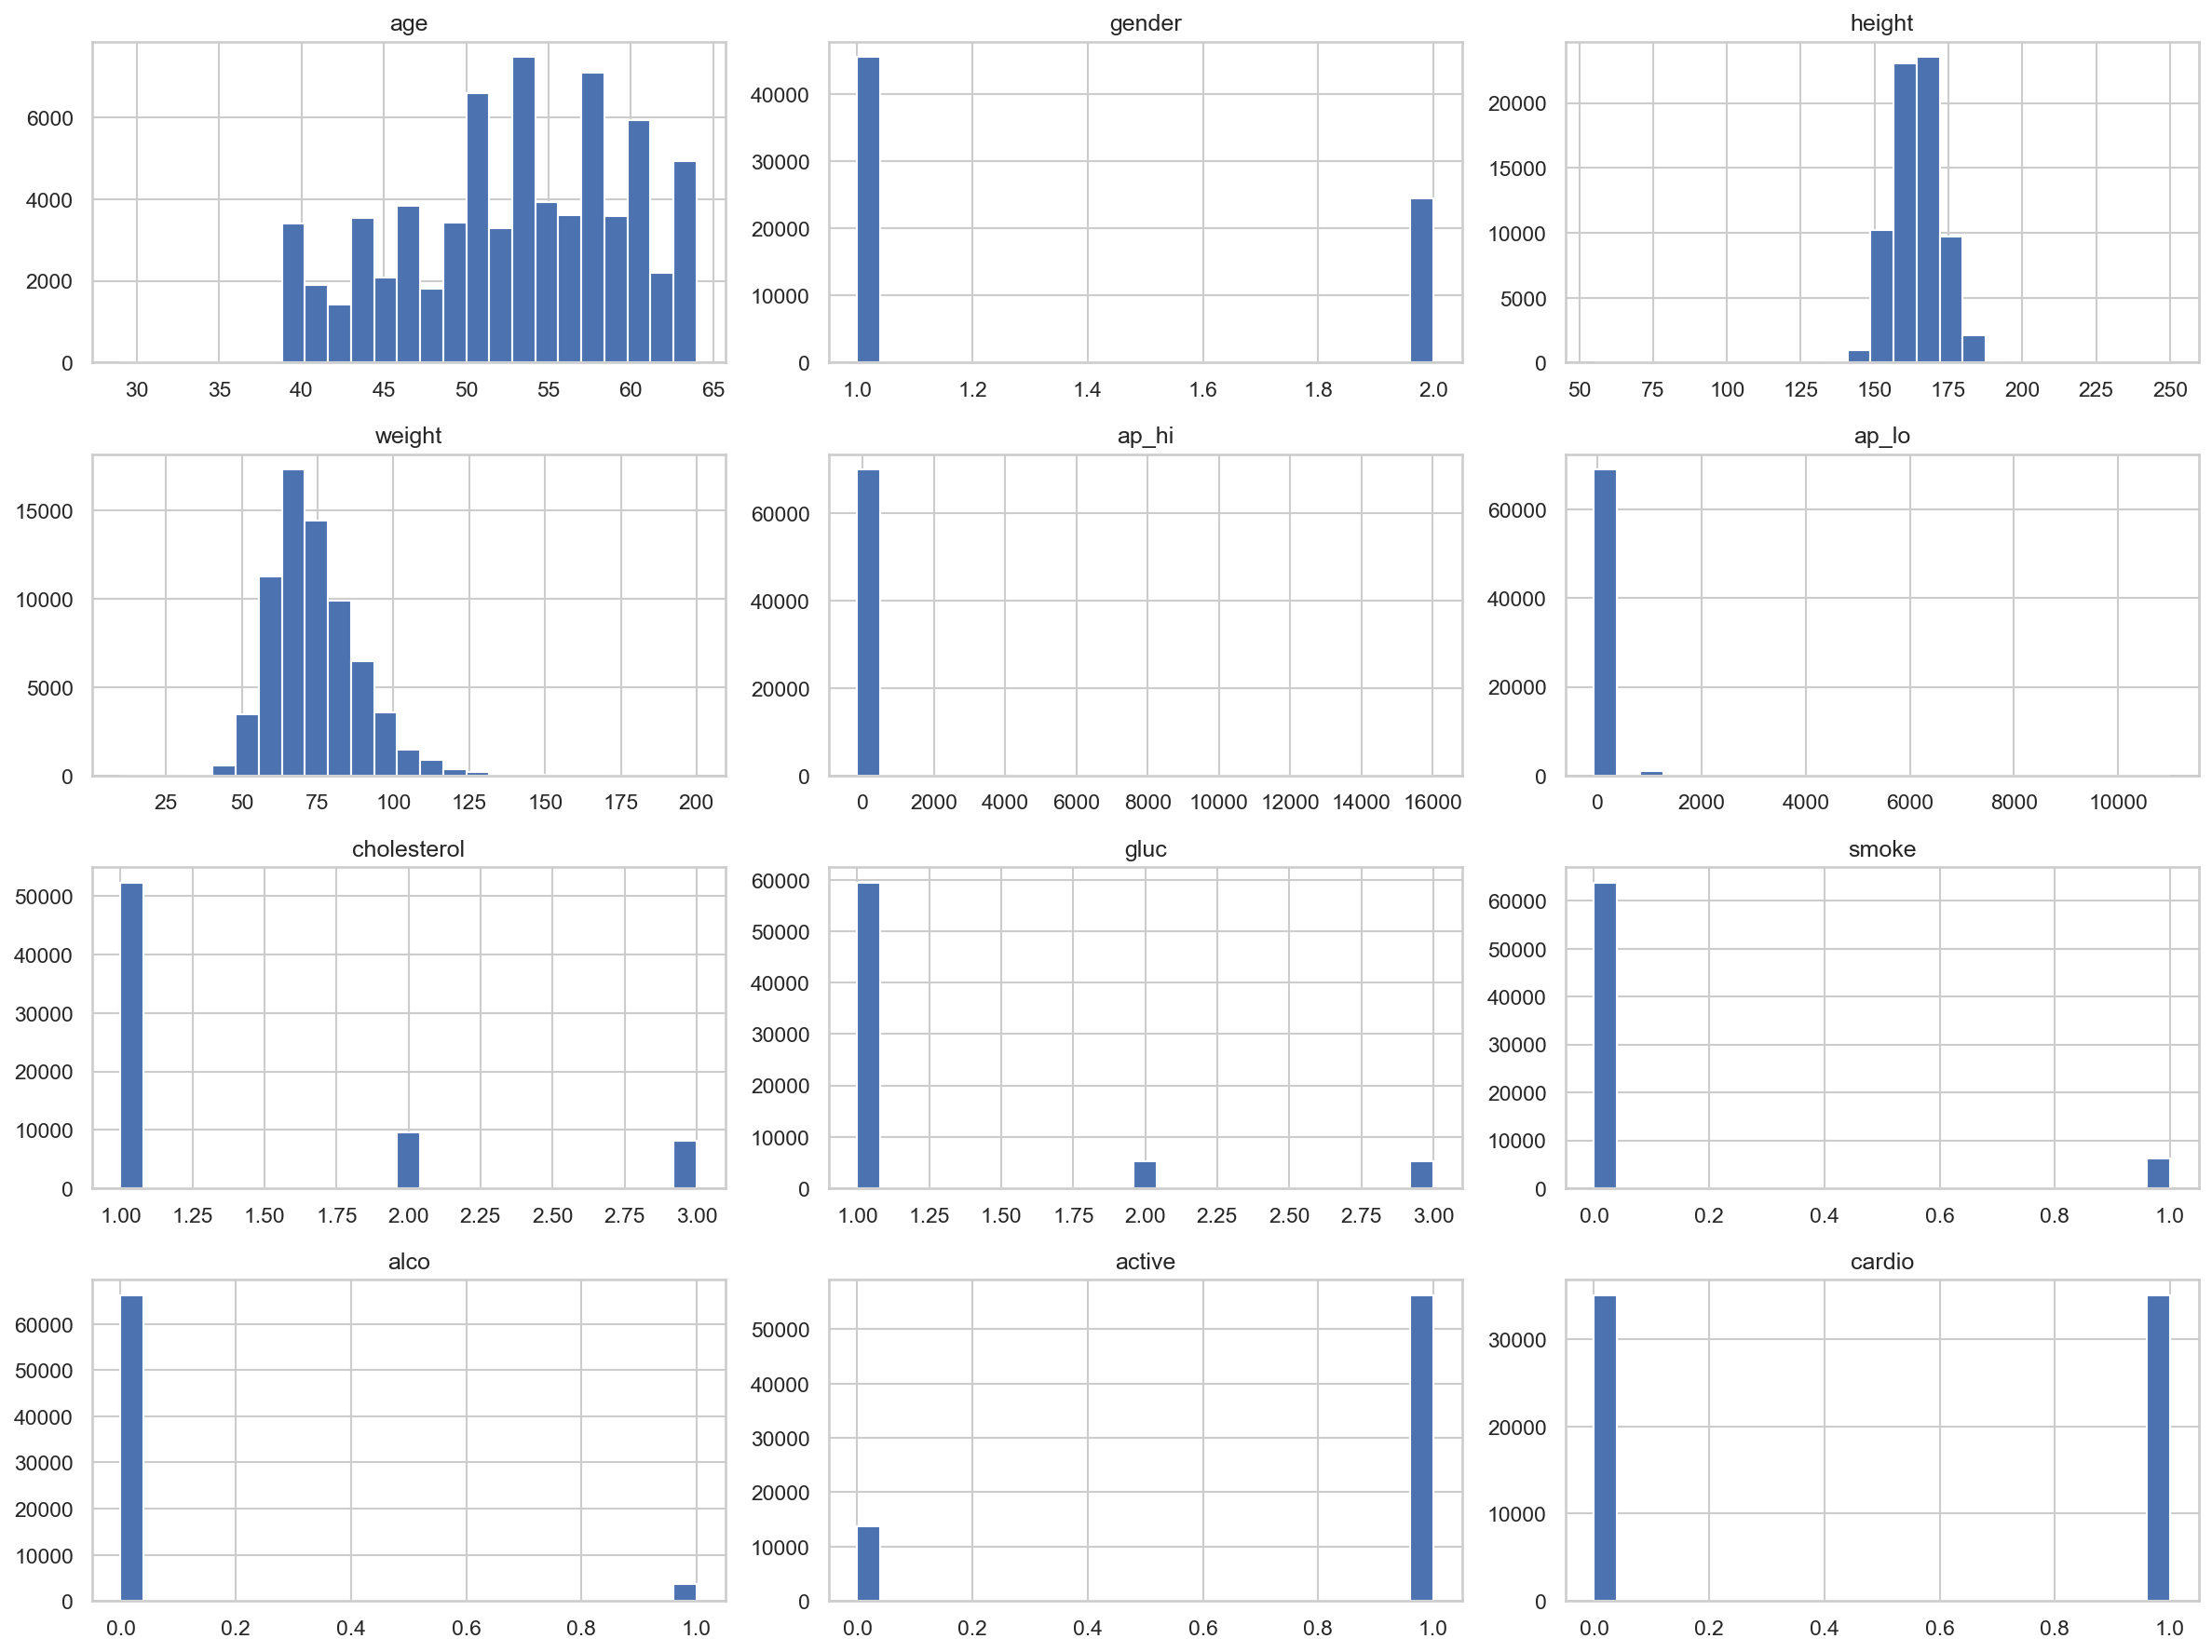

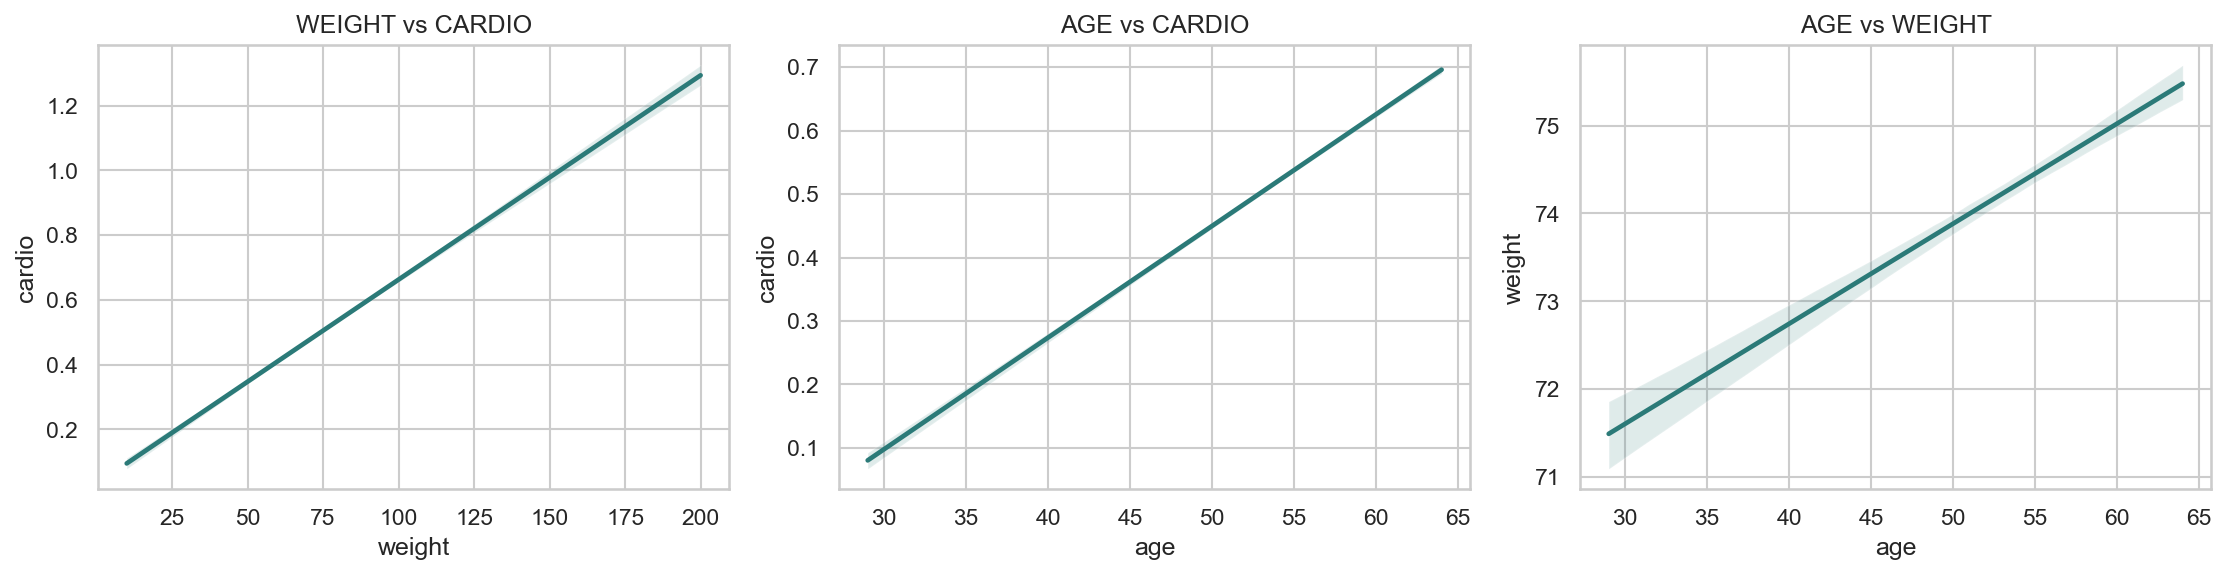

In [2]:
counts=df.cardio.value_counts().sort_index()
plt.figure(figsize=(6,4)); counts.plot.bar(color=['#2b7a78','#d35d6e'])
plt.xticks([0,1],['Không mắc bệnh','Mắc bệnh'],rotation=0)
plt.ylabel('Số hồ sơ'); plt.title('Phân bố nhãn CARDIO')
figure('01_target_distribution.png')
corr=df[features+['cardio']].corr()
display(corr.cardio.sort_values(ascending=False))
plt.figure(figsize=(12,9)); sns.heatmap(corr,annot=True,fmt='.2f',cmap='RdYlGn',vmin=-1,vmax=1)
plt.title('Tương quan Pearson trước xử lý ngoại lệ')
figure('02_correlation_raw.png')
df[features+['cardio']].hist(figsize=(16,12),bins=25)
figure('03_histograms.png')
fig,axs=plt.subplots(1,3,figsize=(15,4))
for ax,(x,y) in zip(axs,[('weight','cardio'),('age','cardio'),('age','weight')]):
    sns.regplot(data=df,x=x,y=y,ax=ax,scatter=False,line_kws={'color':'#2b7a78'})
    ax.set_title(x.upper()+' vs '+y.upper())
figure('04_regression_relationships.png')

## 3. Làm sạch huyết áp bằng IQR
Với mỗi cột AP_HI/AP_LO: IQR = Q3 − Q1; cận dưới = Q1 − 1,5×IQR; cận trên = Q3 + 1,5×IQR.
Thay giá trị ngoài khoảng bằng cận tương ứng như code mẫu. Bảng này dùng toàn bộ dữ liệu cho EDA/thống kê.
Khi đánh giá mô hình ở phần 5, các cận sẽ được học lại chỉ trên dữ liệu huấn luyện trong Pipeline.

,column,q1,q3,iqr,lower,upper,modified_rows
0,ap_hi,120.0,140.0,20.0,90.0,170.0,1435
1,ap_lo,80.0,90.0,10.0,65.0,105.0,4632


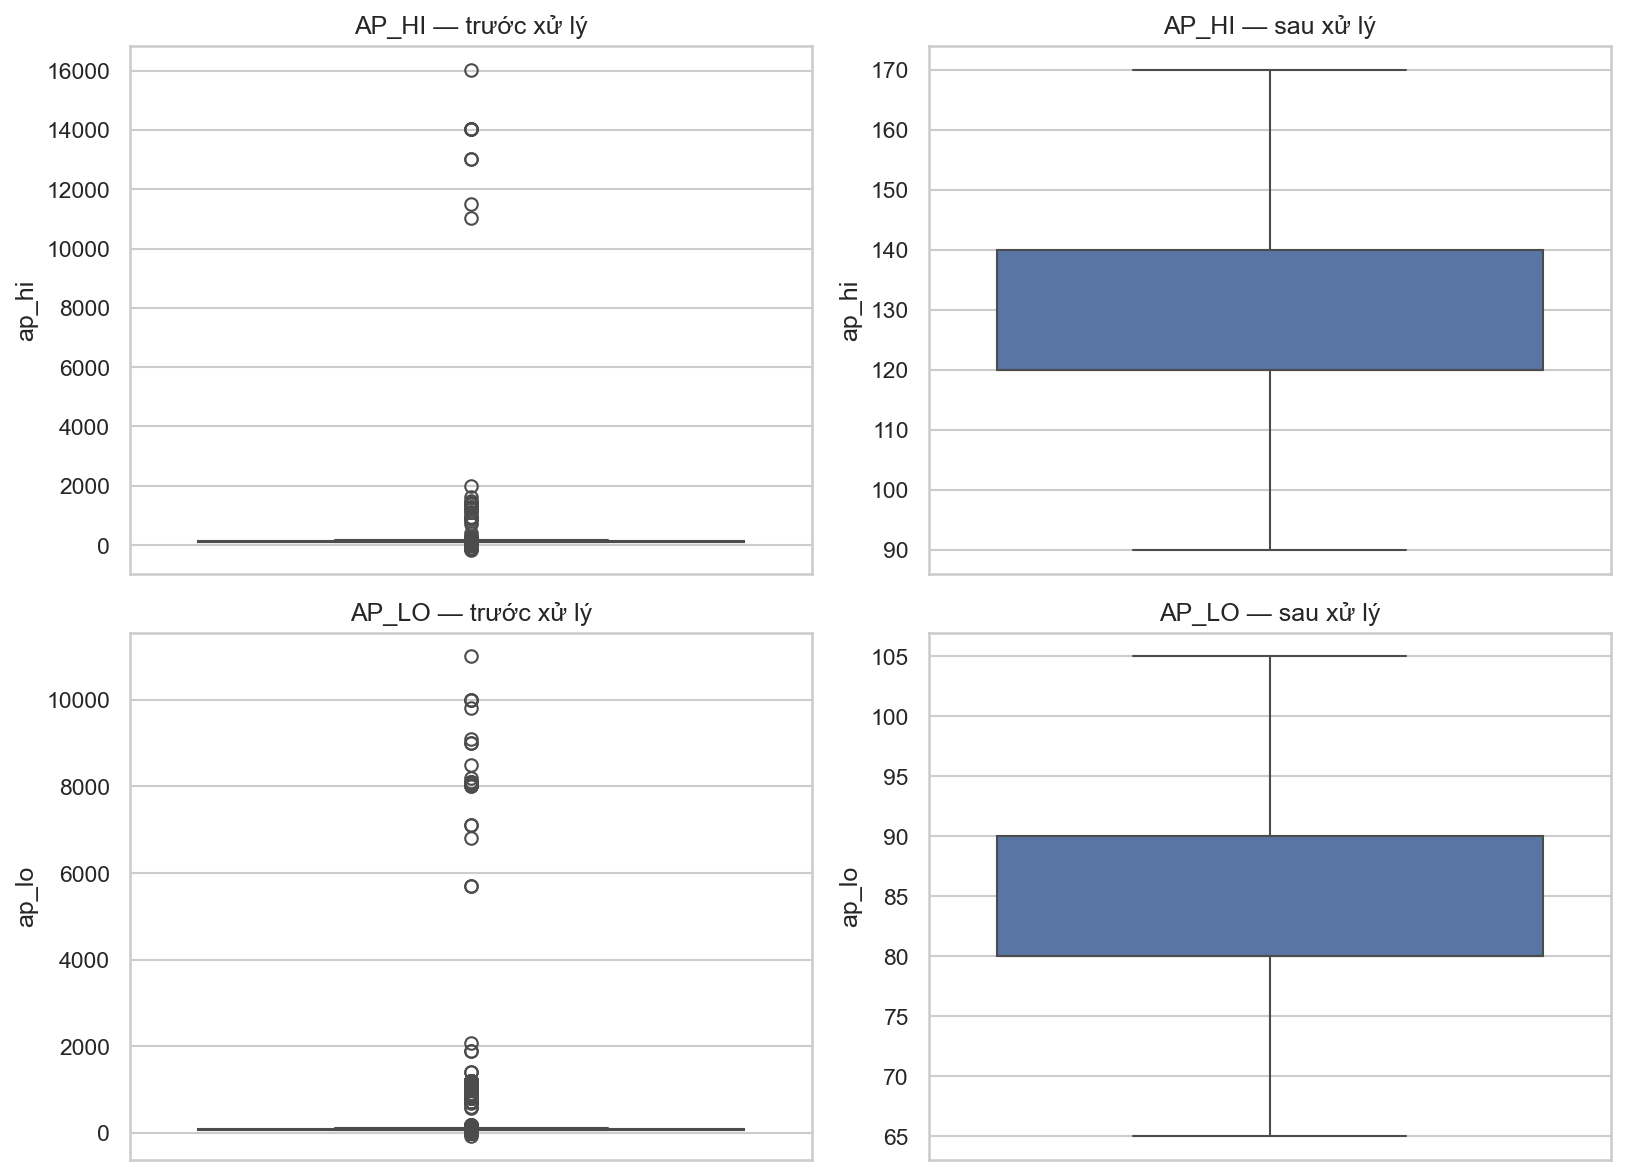

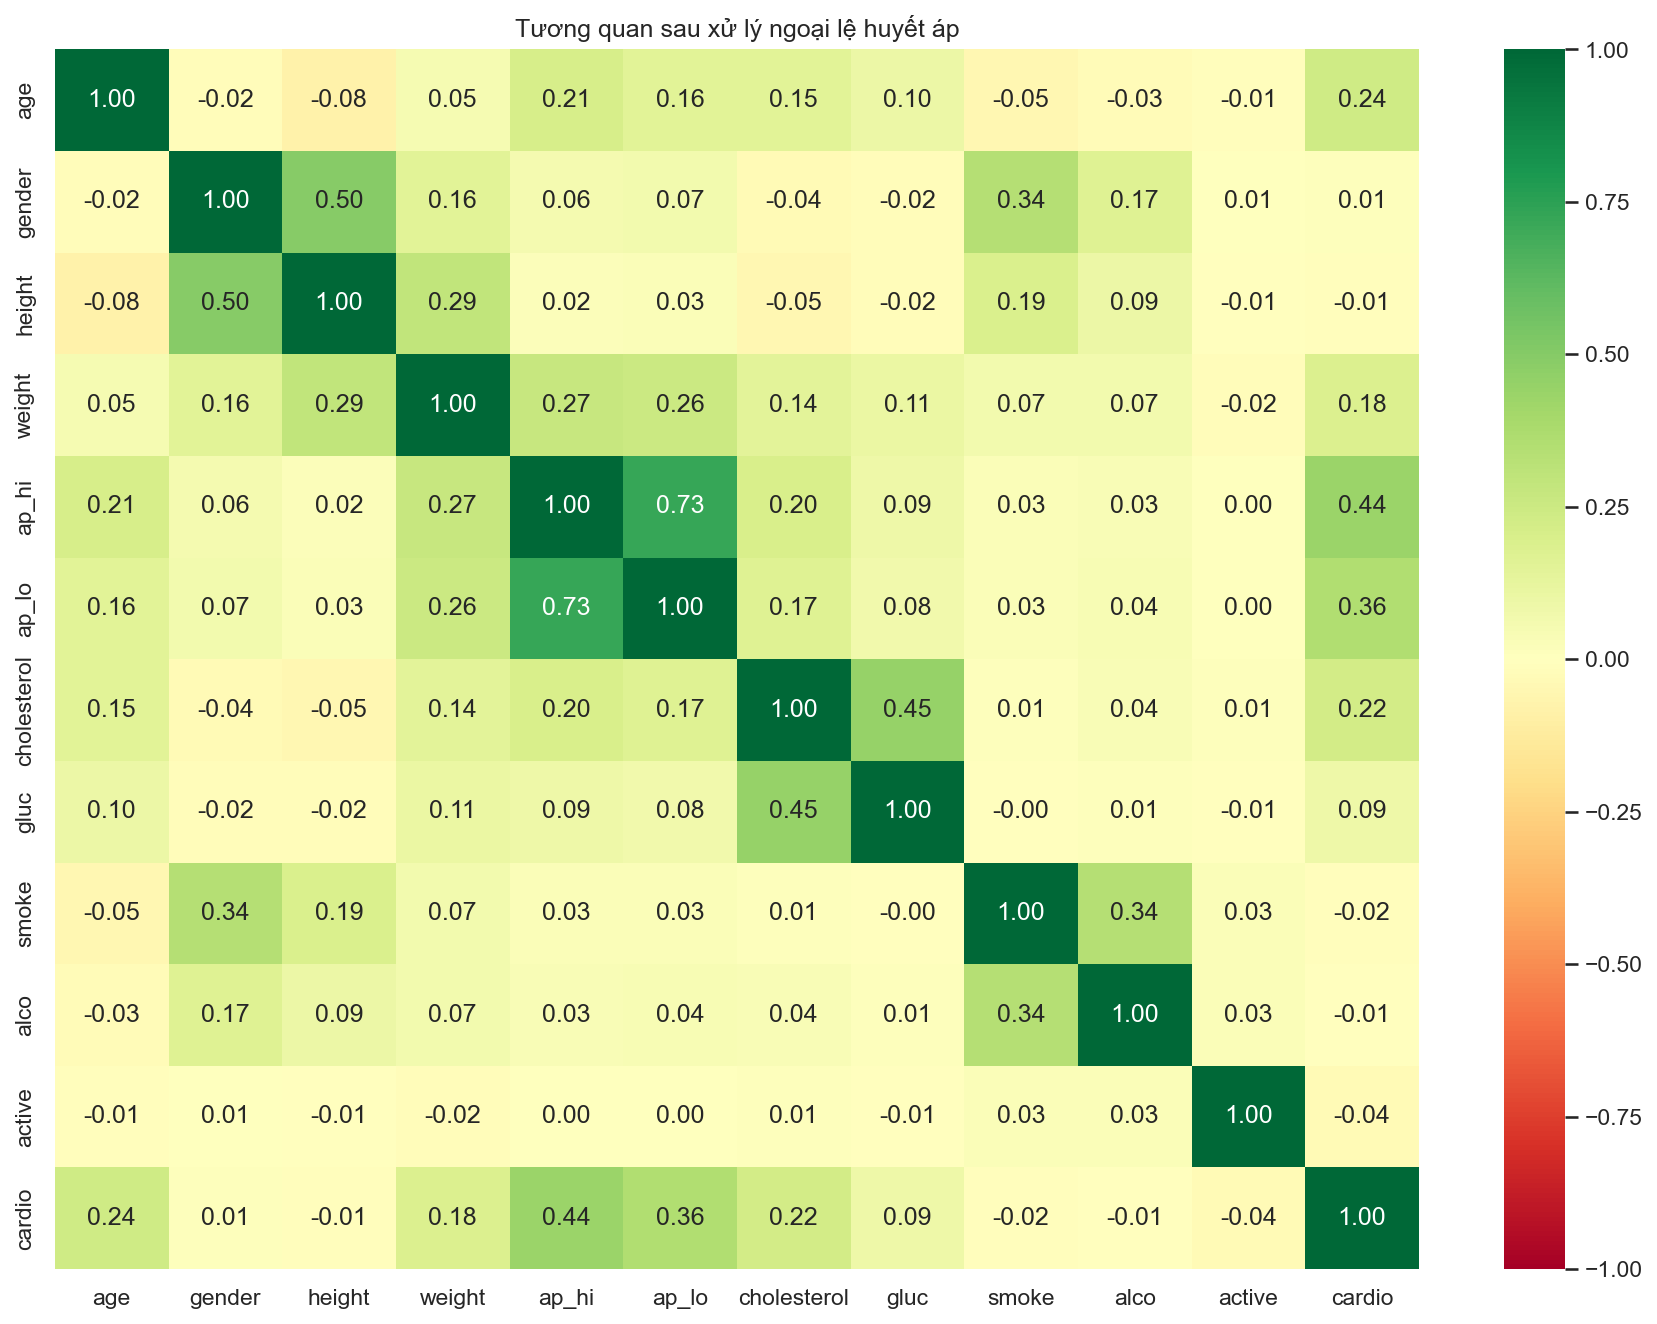

In [3]:
clean=df.copy(); limits=[]
for col in ['ap_hi','ap_lo']:
    q1,q3=df[col].quantile([.25,.75]); iqr=q3-q1
    lower,upper=q1-1.5*iqr,q3+1.5*iqr
    mask=(df[col]<lower)|(df[col]>upper)
    limits.append({'column':col,'q1':q1,'q3':q3,'iqr':iqr,'lower':lower,'upper':upper,'modified_rows':int(mask.sum())})
    clean[col]=df[col].clip(lower,upper)
limits=pd.DataFrame(limits); display(limits)
limits.to_csv(ROOT/'results/iqr_limits.csv',index=False)
clean.to_csv(ROOT/'data/cardio_train_clean.csv',index=False)
fig,axs=plt.subplots(2,2,figsize=(11,8))
for i,col in enumerate(['ap_hi','ap_lo']):
    sns.boxplot(y=df[col],ax=axs[i,0]); axs[i,0].set_title(col.upper()+' — trước xử lý')
    sns.boxplot(y=clean[col],ax=axs[i,1]); axs[i,1].set_title(col.upper()+' — sau xử lý')
figure('05_boxplots_before_after.png')
plt.figure(figsize=(12,9)); sns.heatmap(clean[features+['cardio']].corr(),annot=True,fmt='.2f',cmap='RdYlGn',vmin=-1,vmax=1)
plt.title('Tương quan sau xử lý ngoại lệ huyết áp')
figure('06_correlation_clean.png')

## 4. Kiểm định thống kê theo đề
Ngưỡng ý nghĩa α = 0,05. Bác bỏ H0 khi p < 0,05; nếu p ≥ 0,05 thì chưa đủ bằng chứng bác bỏ H0.
ANOVA/T-test trên nhãn nhị phân và OLS được giữ để bám theo ví dụ bài tập, nhưng không phải bộ phân loại cuối.
Chi-square bổ sung cho cholesterol và tương quan point-biserial cho cân nặng phù hợp với bản chất nhãn nhị phân.
Giá trị p rất nhỏ có thể bị máy tính làm tròn thành 0; không diễn giải thành xác suất bằng 0 tuyệt đối.

In [4]:
tests=[]
f,p=stats.f_oneway(*(clean.loc[clean.cholesterol==k,'cardio'] for k in [1,2,3]))
tests.append(['ANOVA: cholesterol vs cardio',float(f),float(p)])
low=clean.loc[clean.age<clean.age.mean(),'cardio']; high=clean.loc[clean.age>=clean.age.mean(),'cardio']
lev,lev_p=stats.levene(low,high,center='mean')
t,p=stats.ttest_ind(low,high,equal_var=lev_p>.05)
tests.append(['T-test: hai nhóm tuổi',float(t),float(p)])
r,p=stats.pearsonr(clean.weight,clean.cardio)
tests.append(['Pearson: weight vs cardio',float(r),float(p)])
chi,p,dof,expected=stats.chi2_contingency(pd.crosstab(clean.alco,clean.cardio),correction=True)
tests.append(['Chi-square: alco vs cardio',float(chi),float(p)])
chi,p,_,_=stats.chi2_contingency(pd.crosstab(clean.cholesterol,clean.cardio))
tests.append(['Chi-square bổ sung: cholesterol',float(chi),float(p)])
tests=pd.DataFrame(tests,columns=['test','statistic','p_value'])
tests['conclusion']=np.where(tests.p_value<.05,'Bác bỏ H0','Chưa đủ bằng chứng bác bỏ H0')
display(tests)
print(f'Levene: statistic={lev:.6g}; p={lev_p:.6g}; equal_var={lev_p>.05}')
print(f'Tỷ lệ bệnh nhóm tuổi thấp: {low.mean():.2%}; nhóm tuổi cao: {high.mean():.2%}')
tests.to_csv(ROOT/'results/statistical_tests.csv',index=False)
ols=sm.OLS(clean.cardio,sm.add_constant(clean[features].astype(float))).fit()
print(ols.summary())
(ROOT/'results/ols_summary.txt').write_text(ols.summary().as_text(),encoding='utf-8')
ols_table=pd.DataFrame({'feature':ols.params.index,'coefficient':ols.params.values,'p_value':ols.pvalues.values})
ols_table.to_csv(ROOT/'results/ols_coefficients.csv',index=False)

Levene: statistic=133.983; p=5.88007e-31; equal_var=False
Tỷ lệ bệnh nhóm tuổi thấp: 39.15%; nhóm tuổi cao: 58.71%
                            OLS Regression Results                            
Dep. Variable:                 cardio   R-squared:                       0.235
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     1954.
Date:                Tue, 06 Oct 2026   Prob (F-statistic):               0.00
Time:                        15:57:05   Log-Likelihood:                -41431.
No. Observations:               70000   AIC:                         8.289e+04
Df Residuals:                   69988   BIC:                         8.300e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
---------------

,test,statistic,p_value,conclusion
0,ANOVA: cholesterol vs cardio,1799.660786,0.000000,Bác bỏ H0
1,T-test: hai nhóm tuổi,-52.513509,0.000000,Bác bỏ H0
2,Pearson: weight vs cardio,0.181660,0.000000,Bác bỏ H0
3,Chi-square: alco vs cardio,3.696547,0.054525,Chưa đủ bằng chứng bác bỏ H0
4,Chi-square bổ sung: cholesterol,3423.438898,0.000000,Bác bỏ H0


## 5. Chia dữ liệu, chuẩn hóa và huấn luyện
Chia 70% train (49.000) và 30% test (21.000), random_state=42, phân tầng theo CARDIO.
AP_HI/AP_LO được chặn theo IQR trong Pipeline. StandardScaler chỉ áp dụng AGE, HEIGHT, WEIGHT, AP_HI, AP_LO.
Mã giới tính và các biến phân loại/nhị phân được giữ theo ví dụ của đề.
GridSearchCV dùng 3 fold của tập train để chọn Gradient Boosting trước khi xem điểm test.
Accuracy là chỉ tiêu đề yêu cầu; thêm Precision, Recall, F1 và ROC-AUC để nhận xét đầy đủ.

In [5]:
X=df[features]; y=df.cardio
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.3,random_state=42,stratify=y)
pd.DataFrame({'id':raw.loc[X_train.index,'id'],'split':'train'}).to_csv(ROOT/'results/train_ids.csv',index=False)
pd.DataFrame({'id':raw.loc[X_test.index,'id'],'split':'test'}).to_csv(ROOT/'results/test_ids.csv',index=False)
assert len(X_train)==49000 and len(X_test)==21000
assert set(raw.loc[X_train.index,'id']).isdisjoint(set(raw.loc[X_test.index,'id']))
num_idx=[0,2,3,4,5]; cat_idx=[1,6,7,8,9,10]
def pipeline(model):
    return Pipeline([('iqr',IQRClipper(columns=(4,5))),
        ('scale',ColumnTransformer([('numeric',StandardScaler(),num_idx),('categorical','passthrough',cat_idx)])),
        ('model',model)])
print('Train:',X_train.shape,'Test:',X_test.shape)
print('Tỷ lệ bệnh train/test:',y_train.mean(),y_test.mean())
search=GridSearchCV(pipeline(GradientBoostingClassifier(random_state=42)),
    {'model__n_estimators':[100,150],'model__learning_rate':[.05,.1],'model__max_depth':[2,3]},
    scoring='accuracy',cv=StratifiedKFold(n_splits=3,shuffle=True,random_state=42),n_jobs=1,refit=True)
start=time.perf_counter(); search.fit(X_train,y_train)
cv_table=pd.DataFrame(search.cv_results_)
display(cv_table[['params','mean_test_score','std_test_score','rank_test_score']].sort_values('rank_test_score'))
cv_table[['params','mean_test_score','std_test_score','rank_test_score']].to_csv(ROOT/'results/grid_search.csv',index=False)
print('Tham số tốt nhất:',search.best_params_,'CV Accuracy:',search.best_score_,'Thời gian:',round(time.perf_counter()-start,1),'giây')

Train: (49000, 11) Test: (21000, 11)
Tỷ lệ bệnh train/test: 0.4996938775510204 0.4997142857142857
Tham số tốt nhất: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 150} CV Accuracy: 0.7368775512177198 Thời gian: 66.2 giây


,params,mean_test_score,std_test_score,rank_test_score
5,"{'model__learning_rate': 0.1, 'model__max_dept...",0.736878,0.001575,1
4,"{'model__learning_rate': 0.1, 'model__max_dept...",0.736388,0.001498,2
3,"{'model__learning_rate': 0.05, 'model__max_dep...",0.736184,0.002130,3
7,"{'model__learning_rate': 0.1, 'model__max_dept...",0.736102,0.001592,4
6,"{'model__learning_rate': 0.1, 'model__max_dept...",0.735837,0.001794,5
2,"{'model__learning_rate': 0.05, 'model__max_dep...",0.735551,0.001687,6
1,"{'model__learning_rate': 0.05, 'model__max_dep...",0.735122,0.001755,7
0,"{'model__learning_rate': 0.05, 'model__max_dep...",0.732265,0.001480,8


Dummy baseline: accuracy=0.5003; 0.0s
RidgeClassifier: accuracy=0.7241; 0.1s
RandomForest: accuracy=0.7091; 7.0s
GradientBoosting: accuracy=0.7317; 3.4s
AdaBoost: accuracy=0.7259; 2.1s
Bagging KNN: accuracy=0.7165; 8.5s
ExtraTrees: accuracy=0.6931; 7.0s
Stacking: accuracy=0.7288; 20.2s
GradientBoosting tuned (CV): accuracy=0.7304; 0.1s


,model,accuracy,precision,recall,f1,roc_auc,fit_evaluate_seconds
3,GradientBoosting,0.731667,0.748593,0.697160,0.721962,0.799457,3.403566
8,GradientBoosting tuned (CV),0.730429,0.745455,0.699352,0.721668,0.798141,0.083352
7,Stacking,0.728810,0.746077,0.693253,0.718696,0.791590,20.203476
4,AdaBoost,0.725905,0.765107,0.651515,0.703757,0.792569,2.125686
1,RidgeClassifier,0.724095,0.755824,0.661616,0.705589,0.786472,0.051290
5,Bagging KNN,0.716524,0.737823,0.671241,0.702959,0.776544,8.467843
2,RandomForest,0.709143,0.712048,0.701734,0.706854,0.764956,6.993224
6,ExtraTrees,0.693095,0.694570,0.688679,0.691612,0.740671,6.967115
0,Dummy baseline,0.500286,0.000000,0.000000,0.000000,0.500000,0.018048


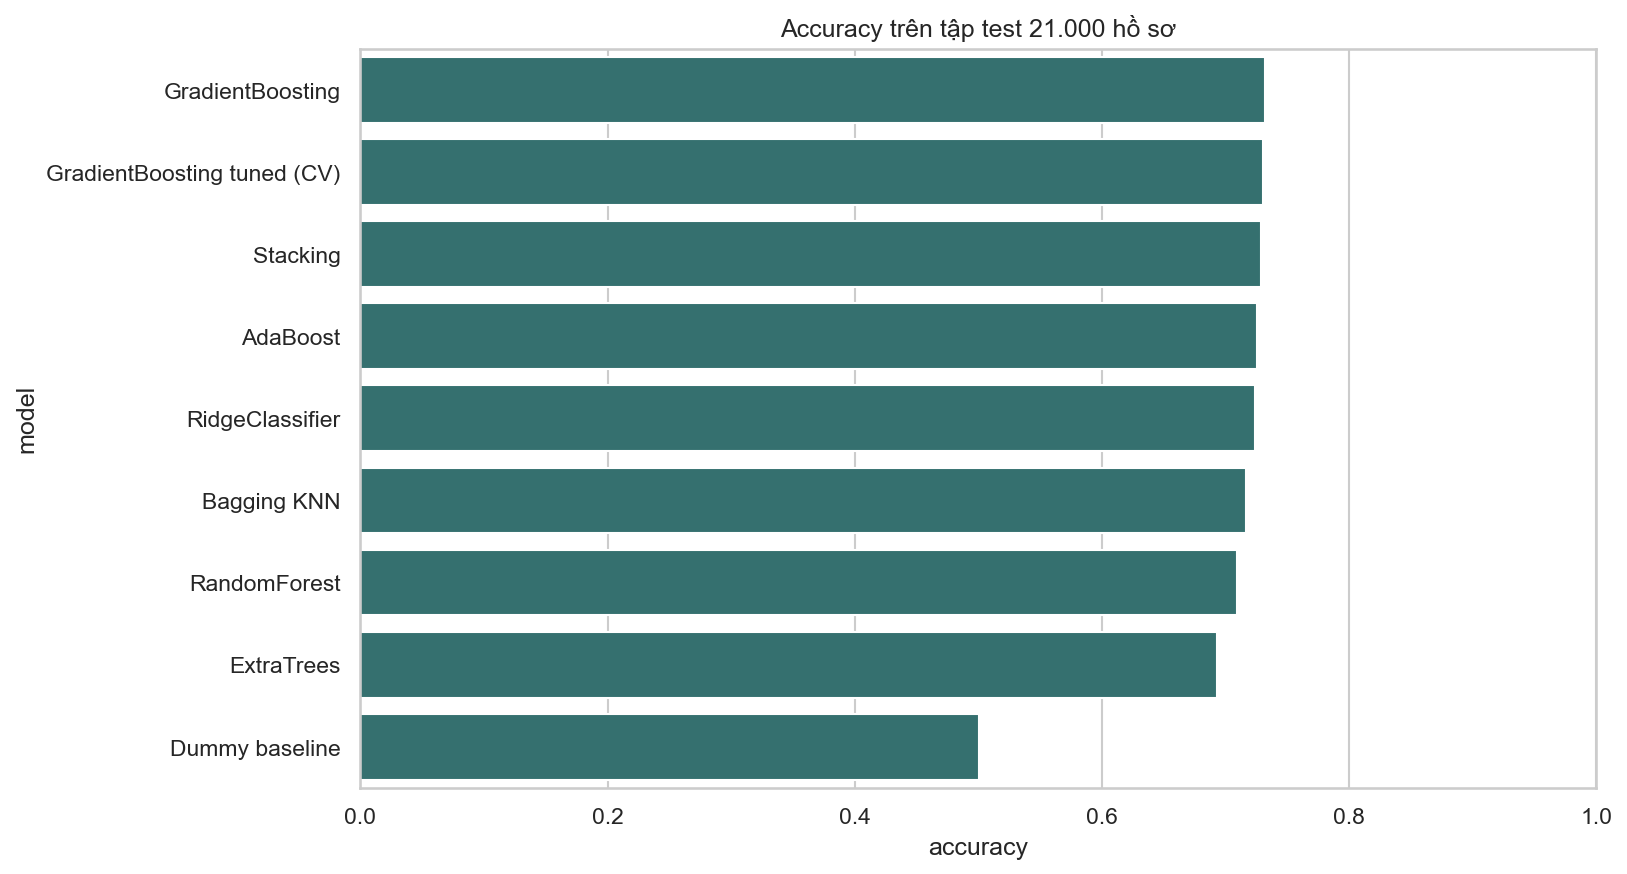

In [6]:
stacking=StackingClassifier(estimators=[('ridge',RidgeClassifier()),
    ('knn',KNeighborsClassifier(n_neighbors=20,metric='euclidean'))],
    final_estimator=GradientBoostingClassifier(n_estimators=25,subsample=.5,min_samples_leaf=25,max_features=1,random_state=42),
    cv=3,n_jobs=1)
# Each stacking base estimator owns its preprocessing, so its out-of-fold predictions do not leak validation data.
stacking=StackingClassifier(estimators=[('ridge',pipeline(RidgeClassifier())),
    ('knn',pipeline(KNeighborsClassifier(n_neighbors=20,metric='euclidean')))],
    final_estimator=GradientBoostingClassifier(n_estimators=25,subsample=.5,min_samples_leaf=25,max_features=1,random_state=42),
    cv=StratifiedKFold(n_splits=3,shuffle=True,random_state=42),n_jobs=1)
models={
    'Dummy baseline':DummyClassifier(strategy='most_frequent'),
    'RidgeClassifier':pipeline(RidgeClassifier(alpha=.0001)),
    'RandomForest':pipeline(RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=1)),
    'GradientBoosting':pipeline(GradientBoostingClassifier(random_state=42)),
    'AdaBoost':pipeline(AdaBoostClassifier(n_estimators=100,random_state=42)),
    'Bagging KNN':pipeline(BaggingClassifier(estimator=KNeighborsClassifier(),max_samples=.5,max_features=.5,random_state=42,n_jobs=1)),
    'ExtraTrees':pipeline(ExtraTreesClassifier(n_estimators=100,random_state=42,n_jobs=1)),
    'Stacking':stacking,
    'GradientBoosting tuned (CV)':search.best_estimator_,
}
rows=[]; predictions={}
for name,model in models.items():
    start=time.perf_counter()
    if name!='GradientBoosting tuned (CV)': model.fit(X_train,y_train)
    pred=model.predict(X_test); predictions[name]=pred
    score=model.predict_proba(X_test)[:,1] if hasattr(model,'predict_proba') else model.decision_function(X_test)
    rows.append({'model':name,'accuracy':accuracy_score(y_test,pred),
        'precision':precision_score(y_test,pred,zero_division=0),'recall':recall_score(y_test,pred,zero_division=0),
        'f1':f1_score(y_test,pred,zero_division=0),'roc_auc':roc_auc_score(y_test,score),
        'fit_evaluate_seconds':time.perf_counter()-start})
    print(f'{name}: accuracy={rows[-1]["accuracy"]:.4f}; {rows[-1]["fit_evaluate_seconds"]:.1f}s',flush=True)
metrics=pd.DataFrame(rows).sort_values('accuracy',ascending=False)
display(metrics); metrics.to_csv(ROOT/'results/model_comparison.csv',index=False)
plt.figure(figsize=(11,6)); sns.barplot(data=metrics,x='accuracy',y='model',color='#2b7a78')
plt.xlim(0,1); plt.title('Accuracy trên tập test 21.000 hồ sơ')
figure('07_model_comparison.png')

## 6. Đánh giá mô hình đã chọn bằng cross-validation
Mô hình được chọn theo CV của tập train: Gradient Boosting đã tinh chỉnh.
Bảng so sánh test chỉ phục vụ bài tập, không dùng để chọn lại tham số sau khi nhìn test.
Điểm test của nhiều mô hình là so sánh khám phá; đánh giá triển khai cần thêm bộ dữ liệu độc lập.

GradientBoosting tuned (CV)
              precision    recall  f1-score   support

           0     0.7172    0.7615    0.7387     10506
           1     0.7455    0.6994    0.7217     10494

    accuracy                         0.7304     21000
   macro avg     0.7313    0.7304    0.7302     21000
weighted avg     0.7313    0.7304    0.7302     21000



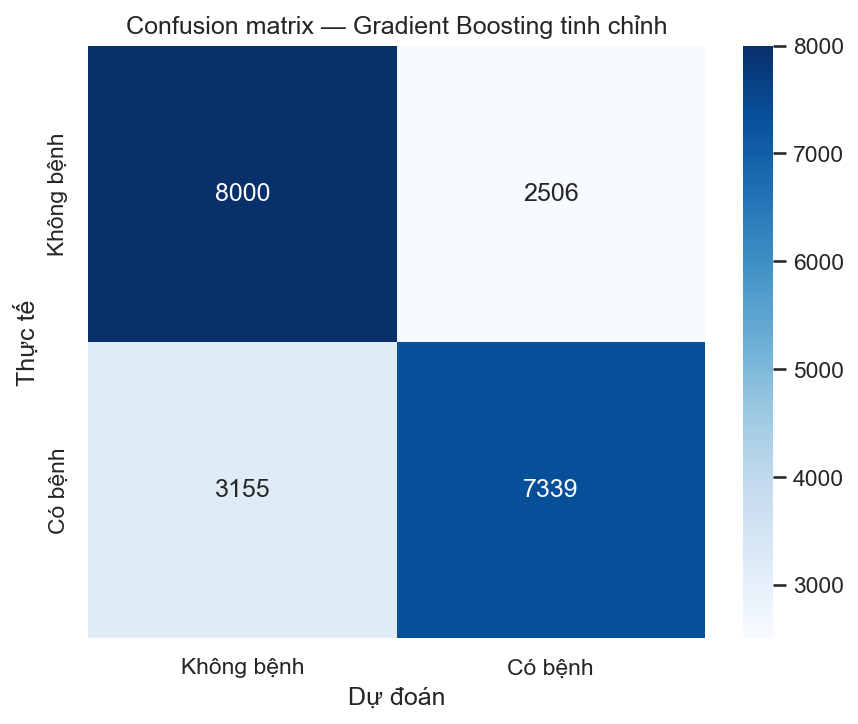

,feature,importance
3,ap_hi,0.749361
0,age,0.122734
6,cholesterol,0.076474
4,ap_lo,0.023438
2,weight,0.015926
10,active,0.003966
7,gluc,0.002473
1,height,0.001841
8,smoke,0.001739
9,alco,0.001547


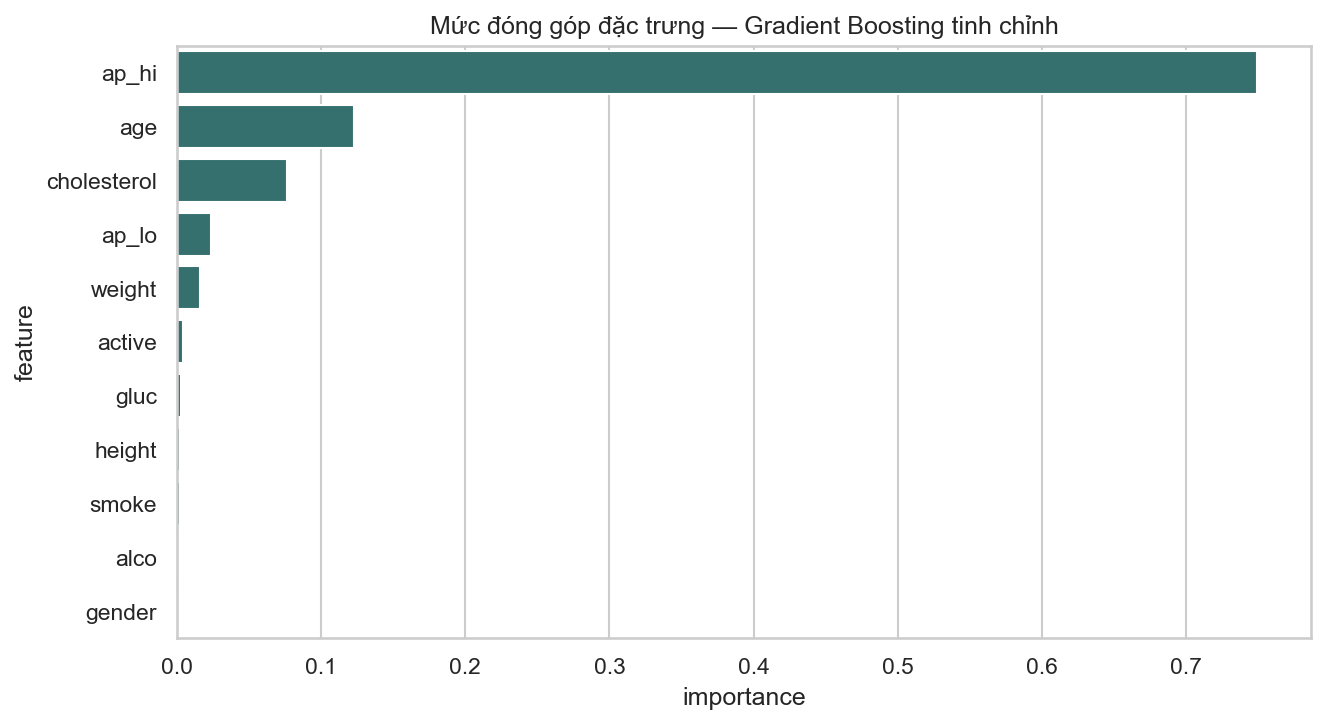

In [7]:
selected='GradientBoosting tuned (CV)'
final_model=models[selected]; pred=predictions[selected]
cm=confusion_matrix(y_test,pred)
print(selected); print(classification_report(y_test,pred,digits=4))
plt.figure(figsize=(6,5)); sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
    xticklabels=['Không bệnh','Có bệnh'],yticklabels=['Không bệnh','Có bệnh'])
plt.xlabel('Dự đoán'); plt.ylabel('Thực tế'); plt.title('Confusion matrix — Gradient Boosting tinh chỉnh')
figure('08_confusion_matrix.png')
names=['age','height','weight','ap_hi','ap_lo','gender','cholesterol','gluc','smoke','alco','active']
importance=pd.DataFrame({'feature':names,'importance':final_model.named_steps['model'].feature_importances_}).sort_values('importance',ascending=False)
display(importance); importance.to_csv(ROOT/'results/feature_importance.csv',index=False)
plt.figure(figsize=(9,5)); sns.barplot(data=importance,x='importance',y='feature',color='#2b7a78')
plt.title('Mức đóng góp đặc trưng — Gradient Boosting tinh chỉnh')
figure('09_feature_importance.png')
output=pd.DataFrame({'id':raw.loc[X_test.index,'id'],'actual':y_test.to_numpy(),'predicted':pred,
    'probability':final_model.predict_proba(X_test)[:,1]})
output.to_csv(ROOT/'results/test_predictions.csv',index=False)
joblib.dump(final_model,ROOT/'results/cardio_classifier.joblib')
selected_row=metrics.set_index('model').loc[selected].to_dict()
summary={'quality':quality,'selected_model':selected,'selected_test_metrics':selected_row,
    'cv_accuracy':float(search.best_score_),'best_params':search.best_params_,'confusion_matrix':cm.tolist(),
    'train_rows':len(X_train),'test_rows':len(X_test),
    'train_iqr_lower':final_model.named_steps['iqr'].lower_.tolist(),
    'train_iqr_upper':final_model.named_steps['iqr'].upper_.tolist(),
    'cloud_executed':False,'github_uploaded':False,
    'versions':{p:metadata.version(p) for p in ['numpy','pandas','scipy','scikit-learn','statsmodels','matplotlib','seaborn']}}
(ROOT/'results/summary.json').write_text(json.dumps(summary,ensure_ascii=False,indent=2),encoding='utf-8')
pd.DataFrame([{'package':k,'version':v} for k,v in summary['versions'].items()]).to_csv(ROOT/'results/environment_versions.csv',index=False)

## 7. Nhận xét và giới hạn
- Dữ liệu nhãn gần cân bằng; cần vượt mức đoán lớp phổ biến khoảng 50%.
- Các huyết áp cực lớn/âm là vấn đề chất lượng dữ liệu; IQR theo đề giảm ảnh hưởng, nhưng không thay thế thẩm định y khoa.
- Các kiểm định kiểm tra mối liên hệ thống kê, không chứng minh nhân quả. P ≥ 0,05 không chứng minh không có liên hệ.
- CARDIO là nhị phân; OLS ở phần thống kê chỉ tái hiện bài mẫu. Phân loại dùng RidgeClassifier/các mô hình ensemble.
- Quy mô dữ liệu lớn có thể khiến p rất nhỏ dù hiệu ứng yếu. Không chỉ đọc p-value mà bỏ qua hệ số tương quan/độ lớn hiệu ứng.
- Giữ hồ sơ trùng đặc trưng để bám mẫu; chưa biết ID có đại diện các cá nhân khác nhau trong thực tế hay không.
- Accuracy có thể khác mẫu do phân tầng, thứ tự truy vấn, random_state và phiên bản thư viện; không giả lập số liệu mẫu.
- Mô hình minh họa học máy trong bài tập, chưa được kiểm định để sử dụng chẩn đoán.

## 8. Watson Studio và GitHub
Bản này đã chạy local; chưa có bằng chứng chạy Cloud. Làm theo README để nhập notebook và dữ liệu vào Watson Studio,
chạy lại toàn bộ, lưu kết quả và ảnh minh chứng của bạn, rồi đưa các file vào repository GitHub.

## Tài liệu tham khảo
- Đề ADY201m 35 trang và PDF dữ liệu 649 trang do người dùng cung cấp.
- [IBM: kết nối Db2 bằng ibm_db](https://www.ibm.com/docs/en/db2/12.1.0?topic=db-connecting-database-server).
- [IBM: tạo và quản lý notebook](https://www.ibm.com/docs/en/ws-and-kc?topic=editor-creating-managing-notebooks).
- [IBM: nạp dữ liệu vào notebook](https://www.ibm.com/docs/en/ws-and-kc?topic=scripts-loading-accessing-data-in-notebook).
- [scikit-learn: tránh rò rỉ dữ liệu](https://scikit-learn.org/1.8/common_pitfalls.html).